In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
df = pd.read_csv("dataset_raw.csv")
df.head(5)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [15]:
print(df.isnull().sum())

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [17]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['City'] = le.fit_transform(df['City'])
df['Membership Type'] = le.fit_transform(df['Membership Type'])
df['Satisfaction Level'] = le.fit_transform(df['Satisfaction Level'])
df['Discount Applied'] = df['Discount Applied'].astype(int)

In [18]:
df.head(8)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,0,29,4,1,1120.20,14,4.6,1,25,1
1,102,1,34,2,2,780.50,11,4.1,0,18,0
2,103,0,43,0,0,510.75,9,3.4,1,42,2
3,104,1,30,5,1,1480.30,19,4.7,0,12,1
4,105,1,27,3,2,720.40,13,4.0,1,55,2
5,106,0,37,1,0,440.80,8,3.1,0,22,0
6,107,0,31,4,1,1150.60,15,4.5,1,28,1
7,108,1,35,2,2,800.90,12,4.2,0,14,0


In [19]:
print(df.corr()['Satisfaction Level'].sort_values(ascending=False))

Satisfaction Level          1.000000
Discount Applied            0.771007
Days Since Last Purchase    0.698878
Items Purchased             0.063794
Age                         0.016819
Membership Type             0.004155
Gender                     -0.003521
Average Rating             -0.012443
City                       -0.025887
Customer ID                -0.032005
Total Spend                -0.060444
Name: Satisfaction Level, dtype: float64


In [21]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
to_drop = list(set(to_drop + ['Customer ID']))

print(to_drop)
df = df.drop(columns=to_drop, errors='ignore')

['Items Purchased', 'Customer ID', 'Average Rating', 'Total Spend']


In [22]:
df.head(8)

,Gender,Age,City,Membership Type,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,0,29,4,1,1,25,1
1,1,34,2,2,0,18,0
2,0,43,0,0,1,42,2
3,1,30,5,1,0,12,1
4,1,27,3,2,1,55,2
5,0,37,1,0,0,22,0
6,0,31,4,1,1,28,1
7,1,35,2,2,0,14,0


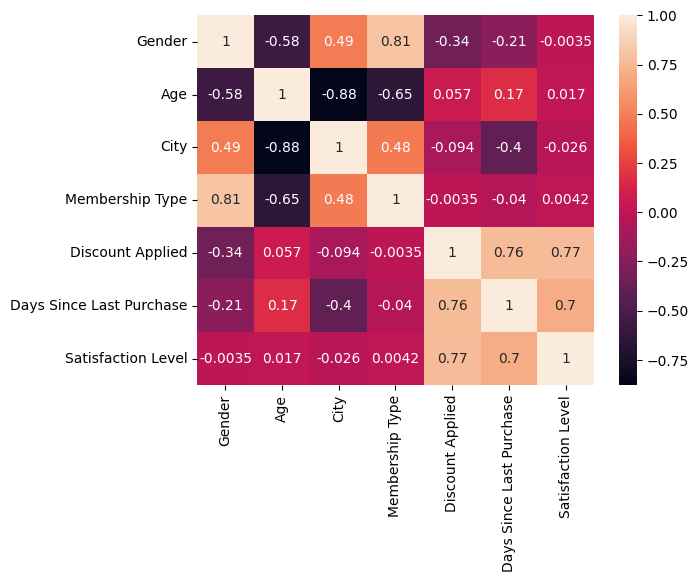

In [23]:
sns.heatmap(df.corr(), annot=True)
plt.show()